In [1]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [2]:
x.requires_grad_(True)  # 等价于x=torch.arange(4.0,requires_grad=True)
x.grad  # 默认值是None

In [3]:
y = 2 * torch.dot(x, x)
y

tensor(28., grad_fn=<MulBackward0>)

In [4]:
y.backward() # 反向传播函数，通过 y 反算出 x，再得到每个 x 的梯度
x.grad

tensor([ 0.,  4.,  8., 12.])

In [5]:
x.grad == 4 * x

tensor([True, True, True, True])

In [6]:
x.grad.zero_()
y = x.sum()
x.grad, y

(tensor([0., 0., 0., 0.]), tensor(6., grad_fn=<SumBackward0>))

In [7]:
y.backward()
x.grad, x.grad == 1.

(tensor([1., 1., 1., 1.]), tensor([True, True, True, True]))

In [8]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x

# 训练神经网络时，我们通常不是分别保留每个样本的梯度，而是先把这一批样本的损失合成一个标量
# 得到的是“这一批样本的平均损失”或者“总损失”对参数的梯度。
# 等价于y.backward(torch.ones(len(x)))
print(y.sum())
y.sum().backward()
x.grad

tensor(14., grad_fn=<SumBackward0>)


tensor([0., 2., 4., 6.])

In [9]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        print(b.norm())
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(), requires_grad=True)
print(a)
d = f(a)
d.backward(retain_graph=True) # 不加 retain_graph=True 会报错，因为 d 的计算图已经被释放了
d, a.grad, d / a

tensor(-0.9521, requires_grad=True)
tensor(1.9042, grad_fn=<CopyBackwards>)
tensor(3.8084, grad_fn=<CopyBackwards>)
tensor(7.6168, grad_fn=<CopyBackwards>)
tensor(15.2335, grad_fn=<CopyBackwards>)
tensor(30.4670, grad_fn=<CopyBackwards>)
tensor(60.9340, grad_fn=<CopyBackwards>)
tensor(121.8681, grad_fn=<CopyBackwards>)
tensor(243.7361, grad_fn=<CopyBackwards>)
tensor(487.4723, grad_fn=<CopyBackwards>)
tensor(974.9446, grad_fn=<CopyBackwards>)


(tensor(-194988.9219, grad_fn=<MulBackward0>),
 tensor(204800.),
 tensor(204800., grad_fn=<DivBackward0>))

## 自动计算导数：我们首先将梯度附加到想要对其计算偏导数的变量上，然后记录目标值的计算，执行它的反向传播函数，并访问得到的梯度。

### 2.5 TEST

In [10]:
# 为什么计算二阶导数比一阶导数的开销要更大？

# 1. 要先算一阶导数，再对一阶导数继续求导，得到 Hessian 矩阵
# 2. 需要保留更多计算图，内存更大 dy_dx = torch.autograd.grad(y, x, create_graph=True)[0], *create_graph=True
# 3. 如果变量是向量/张量，二阶导数不是一个向量，而可能是一个巨大矩阵

In [11]:
import torch

# 重新设计一个带有控制流的函数，且输出关于输入的梯度
def control_flow_grad(x):
    y = x  # 步骤1：将输入张量x赋给y，用于后续操作
    out = torch.tensor(0.0, dtype=x.dtype, device=x.device)  # 步骤2：初始化输出变量out为0，保持x的数据类型和设备一致
    for i in range(5):  # 步骤3：循环5次，体现控制流
        if y.sum() > 0:  # 步骤4：判断当前y的和是否大于0，分支控制
            out = out + y  # 步骤5：如果大于0，将y累加到out
        else:
            out = out - y  # 步骤6：否则，将y从out中减去
        y = y * 2  # 步骤7：每次循环后将y翻倍
    return out  # 步骤8：返回最终out

# 创建一个 requires_grad 的张量
x = torch.randn(3, requires_grad=True)  # 步骤9：随机生成一个长度为3的一维张量，并设置为可求导
print("Input x:", x)  # 步骤10：打印输入x

out = control_flow_grad(x)  # 步骤11：调用带有控制流的函数，得到输出
print("Output of control_flow_grad(x):", out)  # 步骤12：打印输出结果

out.sum().backward()  # 步骤13：对输出的和执行反向传播，计算x的梯度
print("Gradient of x:", x.grad)  # 为什么梯度都是31？因为每个 x[i] 参与了5轮循环，每一轮y翻倍：本质是 x[i] 的梯度累计了 2^0 + 2^1 + 2^2 + 2^3 + 2^4 = 1+2+4+8+16=31，所以每个元素的梯度都是31。

print("out/x: ", out / x)
# 分析：
# 1. 在控制流 (for, if) 下, PyTorch 依然能自动追踪和计算梯度。
# 2. 每轮循环后，y 会变为 y*2，但分支的加法/减法会影响最终的梯度符号和大小。
# 3. grad的大小（除了符号）整体为若干个2的倍数，相当于梯度是每次y对x的累积和。

Input x: tensor([-1.4997,  0.9242,  1.3271], requires_grad=True)
Output of control_flow_grad(x): tensor([-46.4920,  28.6509,  41.1393], grad_fn=<AddBackward0>)
Gradient of x: tensor([31., 31., 31.])
out/x:  tensor([31.0000, 31.0000, 31.0000], grad_fn=<DivBackward0>)


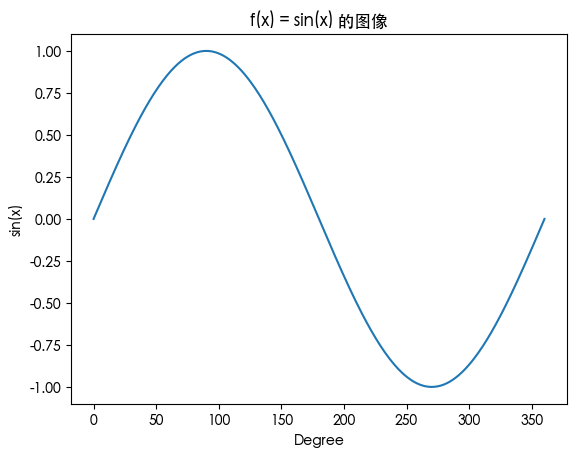

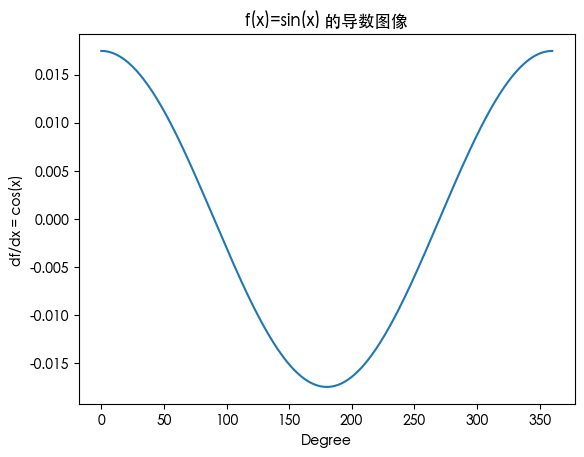

In [ ]:

from matplotlib import font_manager
import matplotlib.pyplot as plt

def f(x):
    return torch.sin(x)

x_vals = torch.linspace(0, 360, steps=300)
y_vals = f(torch.deg2rad(x_vals))

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'STHeiti', 'Arial Unicode MS']  # macOS常用中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

plt.plot(x_vals, y_vals)
plt.xlabel('Degree')
plt.ylabel('sin(x)')
plt.title('f(x) = sin(x) 的图像')
plt.show()

# 这里存在什么问题？为什么会报错？
# 原因：x_vals是用torch.linspace(0, 360, steps=300)创建的，其requires_grad默认是False。
# 因此后面的d也不会有梯度信息(grad_fn)，导致d.sum().backward()报错。
# 解决办法：需要x_vals.requires_grad_()；

x_vals = torch.linspace(0, 360, steps=300, requires_grad=True)
y_vals = f(torch.deg2rad(x_vals))
d = y_vals

# 对 f 关于 x 求导
d_sum = d.sum()
d_sum.backward()  # 这时即可反向传播，不会报错

# 绘制导函数的图像，即 df/dx = cos(x)
# detach() 的作用是将张量从计算图中分离出来，变成普通的张量。这样做能防止后续的绘图操作影响计算图的自动求导过程，也避免无意义的梯度追踪和内存占用。
plt.plot(x_vals.detach(), x_vals.grad.detach())
plt.xlabel('Degree')
plt.ylabel("df/dx = cos(x)")
plt.title('f(x)=sin(x) 的导数图像')
plt.show()